# <b>DESCRIPTION</b>

The overarching objective of the Lakes project is to produce and validate a consistent data set of the variables grouped under the Lakes ECV. More information about the project in: https://climate.esa.int/en/projects/lakes/

This script allows to download remote sensing data from the lakes_cci dataset v3.0.0 for a specific period and within a region defined by the user.

This script is useful for downloading data relating to several lakes in a region whose latitude and longitude boundaries are known.

INPUT:
<ul>
<li>latitude/longitud min and max values </li>
<li>first/last date</li>
    <li>ouptput dir to storage the extracted data in netcdf format</li>
    <li>prefix (optional): to be added at the output files</li>
</ul>
    

<b>Reference</b>: Carrea, L.; Crétaux, J.-F.; Liu, X.; Wu, Y.; Bergé-Nguyen, M.; Calmettes, B.; Duguay, C.; Jiang, D.; Merchant, C.J.; Mueller, D.; Selmes, N.; Simis, S.; Spyrakos, E.; Stelzer, K.; Warren, M.; Yesou, H.; Zhang, D. (2022): ESA Lakes Climate Change Initiative (Lakes_cci): Lake products, Version 2.0.1. NERC EDS Centre for Environmental Data Analysis, date of citation.

https://dx.doi.org/10.5285/7fc9df8070d34cacab8092e45ef276f1

<b>Acknowledgements</b>: This script uses the CCI toolbox (https://climate.esa.int/en/data/toolbox/) and is based in the notebook provided by ESA: https://climate.esa.int/en/projects/lakes/notebook-lakes 


<b>WARNING</b>: If you find a bug, have a question or a suggestion, don't hesitate to contact us, it will be much appreciated : cci_lakes.contact@groupcls.com

<hr/>

## 1. Import packages

In [1]:
from esa_climate_toolbox.core import open_data
from xcube.core.store import new_data_store
import os
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Contents of the lakes_cci dataset

This step is helpful to inspect the structure of the lakes_cci netcdf files. Particulartly, It allows to know:
<ul>
    <li>Spatial coverage</li>
    <li>Temporal coverage</li>
    <li>Name of the variables</li>
</ul>



In [2]:
dataset = 'ESACCI-LAKES-L3S-LK_PRODUCTS-MERGED-fv3.0.0.zarr'
zarr_store = new_data_store('esa-cci-zarr')
dataset_contents = zarr_store.describe_data(dataset)
dataset_contents

## 3. Define parameters. 

In this exemple, we visualise and download data over the region of the Lake Tahoa (USA).

The script execution time depends on the time period defined and the number of variables.
  
In our case, we are looking for data during the month of August 2019: from 2019-08-01 to 2019-08-31. The download step takes around 15 seconds for 3 variables

In [3]:

# defining the zone
# latitude values must be between -90 and 90
# longitud values must be between -180 and 180

lake_name = 'Tahoa'
minlat = 38.8
maxlat = 39.3
minlon = -120.35
maxlon = -119.8

# defining the period of time in string format: YYYY-MM-DD
# dates values must be between 1992-09-26 and 2020-12-31
# WARNING: the  

mindate = '2019-08-01'
maxdate = '2019-08-30'

# output directory
outdir = 'output/Tahoe'
outprefix = 'Tahoe_'

variables = [
  "lake_surface_water_temperature", 
  "lswt_uncertainty",
  "lswt_quality_level"
]


In [4]:
# test if dates are in the temporal coverage
mindate = max([mindate, dataset_contents.time_range[0]])
maxdate = min([maxdate, dataset_contents.time_range[1]])

## 4 Open the Dataset

The lake dataset contains the selected variables on the defined period of time

In [26]:
%%time
time_range = (mindate, maxdate)
region  = [minlon, minlat, maxlon, maxlat]

lakes_ds, _ = open_data(dataset,time_range = time_range, region=region,var_names=variables)

lakes_ds = lakes_ds.load()

# to avoid all the filenames in the source attribut
lakes_ds.attrs['source'] = ';'.join(lakes_ds.source.split(';')[0:-1])

# to remove last date (open_data download maxdate + 1)
lakes_ds.isel(time=slice(0, -1))

lakes_ds

CPU times: user 4.12 s, sys: 406 ms, total: 4.53 s
Wall time: 10.5 s


<xarray.Dataset> Size: 3MB
Dimensions:                         (time: 32, lat: 60, lon: 66)
Coordinates:
  * time                            (time) datetime64[ns] 256B 2019-08-01 ......
  * lat                             (lat) float32 240B 38.8 38.81 ... 39.29 39.3
  * lon                             (lon) float32 264B -120.3 -120.3 ... -119.8
Data variables:
    lake_surface_water_temperature  (time, lat, lon) float64 1MB nan nan ... nan
    lswt_quality_level              (time, lat, lon) float32 507kB nan ... nan
    lswt_uncertainty                (time, lat, lon) float64 1MB nan nan ... nan
Attributes: (12/42)
    Conventions:                CF-1.8
    cdm_data_type:              Grid
    comment:                    These data were produced for the ESA Lakes_cc...
    creator_email:              lakes_cci@groupcls.com
    creator_name:               ESA Lakes_cci
    creator_url:                https://climate.esa.int/en/projects/lakes/
    ...                         ...
    time_coverage_duration:     P1D
    time_coverage_end:          2024-01-01 00:00:00
    time_coverage_resolution:   P1D
    time_coverage_start:        1992-09-26 00:00:00
    title:                      ESA Lakes_cci product
    tracking_id:                f2e77692-0925-4a5d-87fb-eaefa86c8292

In [20]:
lakes_ds.isel(time=slice(0, -1))

<xarray.Dataset> Size: 2MB
Dimensions:                         (time: 31, lat: 60, lon: 66)
Coordinates:
  * time                            (time) datetime64[ns] 248B 2019-08-01 ......
  * lat                             (lat) float32 240B 38.8 38.81 ... 39.29 39.3
  * lon                             (lon) float32 264B -120.3 -120.3 ... -119.8
Data variables:
    lake_surface_water_temperature  (time, lat, lon) float64 982kB nan ... nan
    lswt_quality_level              (time, lat, lon) float32 491kB nan ... nan
    lswt_uncertainty                (time, lat, lon) float64 982kB nan ... nan
Attributes: (12/42)
    Conventions:                CF-1.8
    cdm_data_type:              Grid
    comment:                    These data were produced for the ESA Lakes_cc...
    creator_email:              lakes_cci@groupcls.com
    creator_name:               ESA Lakes_cci
    creator_url:                https://climate.esa.int/en/projects/lakes/
    ...                         ...
    time_coverage_duration:     P1D
    time_coverage_end:          2024-01-01 00:00:00
    time_coverage_resolution:   P1D
    time_coverage_start:        1992-09-26 00:00:00
    title:                      ESA Lakes_cci product
    tracking_id:                f2e77692-0925-4a5d-87fb-eaefa86c8292

## 5. Visualize data for a selected day

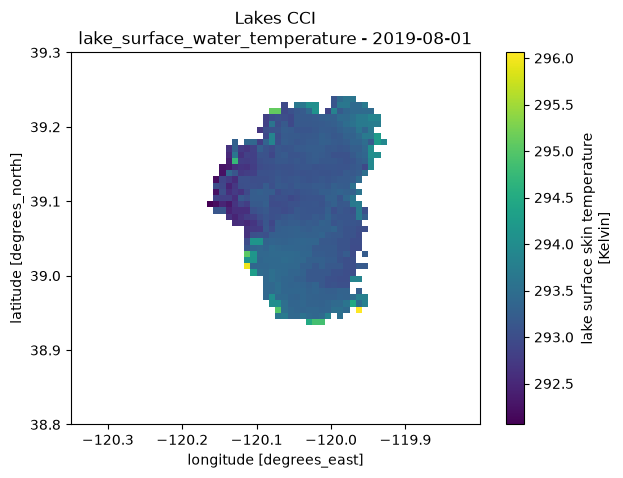

In [6]:
selected_day =  '2019-08-01'
selected_var = 'lake_surface_water_temperature'
daily_var = lakes_ds.sel(time=selected_day)[selected_var]
daily_var.plot()
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.title(f'Lakes CCI\n{selected_var} - {selected_day}')
plt.show()

## 6. Visualise data and histogram for a selected day

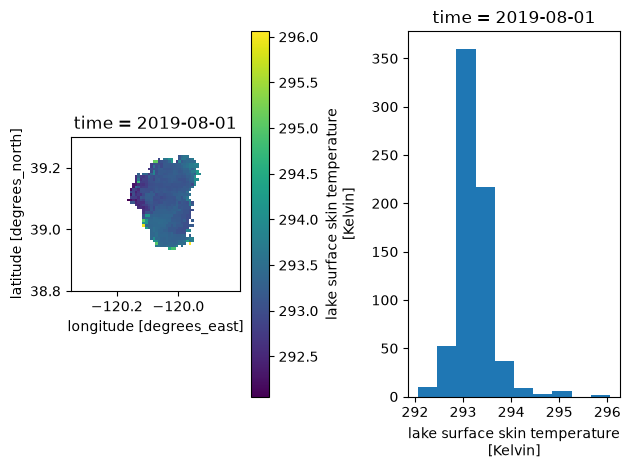

In [7]:
selected_day =  '2019-08-01'
selected_var = 'lake_surface_water_temperature'

fig, axs = plt.subplots(ncols=2)

daily_var = lakes_ds.sel(time = selected_day)[selected_var]
daily_var.plot(ax=axs[0])
axs[0].set_aspect('equal', adjustable='box')
daily_var.plot.hist(ax=axs[1])
plt.tight_layout()

plt.draw()

## 7. Plot multiple metrics: mean, median, max, min, std

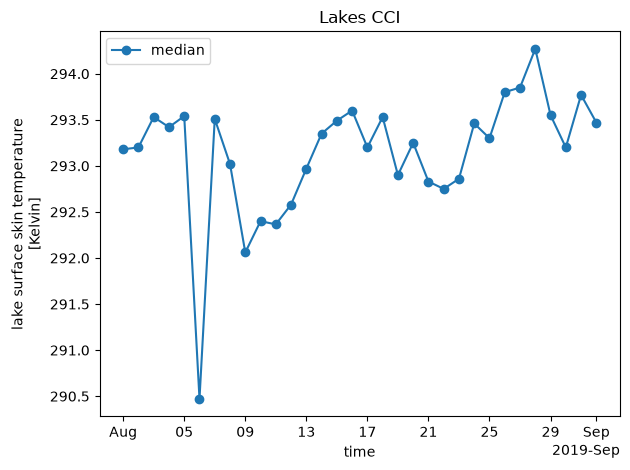

In [21]:

selected_var = "lake_surface_water_temperature"
metric       = "median"
lakes_ds[selected_var].median(("lon", "lat")).plot(marker='o', label=metric)
plt.title(f'Lakes CCI')
plt.legend()
plt.show()

## 8. Visualize two metrics in a single plot

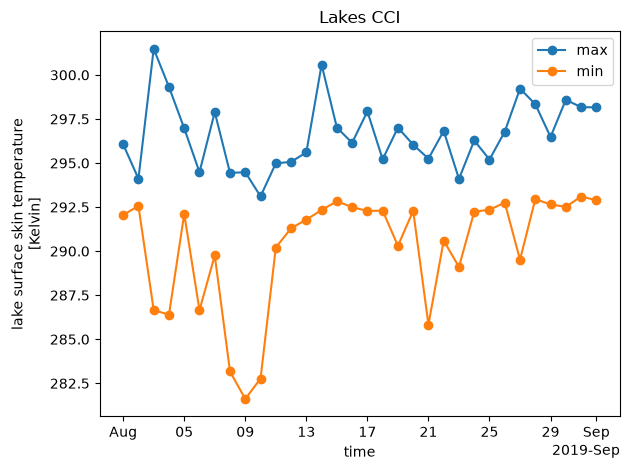

In [22]:
varname = "lake_surface_water_temperature"
lakes_ds[varname].max(("lon", "lat")).plot(marker='o', label = 'max')
lakes_ds[varname].min(("lon", "lat")).plot(marker='o', label = 'min')
plt.title(f'Lakes CCI')
plt.legend()
plt.show()

## 9. Save selecte data in netcdf files

In [12]:
# create the directory if it does not exist
os.makedirs(outdir, exist_ok = True)

# write daily netcdf files
for i in range(lakes_ds.sizes["time"]):
    ds = lakes_ds.isel(time = [i])
    strtime =  str(lakes_ds["time"].values[i]).replace('-', '')[0:8]
    ds.to_netcdf(f"{outdir}/{outprefix}{strtime}.nc")
    
    